# Corporate Wallet Digital Twin V3.1.1 — executed judging notebook

**Team:** Corporate Wallet Digital Twin  
**Member:** Christopher Koen  
**Point-in-time snapshot:** 30 June 2026

This notebook proves the hackathon chain end to end:

`Syn Bank activity + approved public evidence → wallet/share intervals → contestable gap → 20 × 5 heatmap → governed conversation → grounded brief`

> **Claim boundary.** The supplied Syn Bank data is simulated and confidential. Public facts are E1 candidates; only 31 finance-SME-approved facts activate 15 anchors. The other 51 facts are developer-verified candidates and excluded from inference. Competitor share is not measured, economics are representative scenarios, and causal value is withheld.

In [1]:
from pathlib import Path
import hashlib, json, os, sys, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from wallet_twin_v2.offline_lab import _aggregate_historical
from wallet_twin_v2.repository import repository as v2
from wallet_twin_v31.repository import repository as v31

configured = os.getenv('SYNBANK_DATA_ZIP')
private_default = ROOT / 'ref' / 'Data Sets' / 'Data.zip'
archive = Path(configured).expanduser().resolve() if configured else private_default
mode = 'PRIVATE_EVALUATOR' if archive.exists() else 'PUBLIC_MIRROR'
print('Mode:', mode)
print('Version:', v31.metadata['version'], '| as of:', v31.as_of)
print('Bank production:', v31.release['bank_production_status'])

Mode: PRIVATE_EVALUATOR
Version: 3.1.1 | as of: 2026-06-30
Bank production: NOT_PROMOTABLE


## 1. Source archive, hash, member list and data-quality boundary

In [2]:
if mode == 'PRIVATE_EVALUATOR':
    archive_hash = hashlib.sha256(archive.read_bytes()).hexdigest()
    with zipfile.ZipFile(archive) as zf:
        members = [{'member': item.filename, 'compressed_bytes': item.compress_size, 'bytes': item.file_size} for item in zf.infolist()]
    display(pd.DataFrame(members))
    print('Data.zip SHA-256:', archive_hash)
    monthly, raw_counts = _aggregate_historical(archive)
else:
    archive_hash = 'PUBLIC_MIRROR_INDEPENDENTLY_GENERATED_FIXTURE'
    cells = v31.wallet_portfolio(v31.as_of).cells
    monthly = pd.DataFrame([{
        'entity_id': cell.entity_id, 'sector': cell.sector, 'month': '2026-06',
        'product': cell.product, 'amount_zar': float(cell.observed_activity.normalized_amount)
    } for cell in cells])
    raw_counts = {'independently_generated_aggregate_rows': len(monthly)}
print('Raw/fixture row counts:', raw_counts)
print('Monthly aggregate rows:', len(monthly), '| clients:', monthly.entity_id.nunique(), '| products:', monthly['product'].nunique())
assert monthly.entity_id.nunique() == 20 and monthly['product'].nunique() == 5

,member,compressed_bytes,bytes
0,transactional_banking.csv,61623459,392854065
1,__MACOSX/._transactional_banking.csv,86,163
2,trade_finance.csv,572692,3245811
3,__MACOSX/._trade_finance.csv,86,163
4,cross_border_payments.csv,5866552,33003150
5,__MACOSX/._cross_border_payments.csv,86,163


Data.zip SHA-256: 21f0ed75da260b87abfd17df30f210dd91345068672f8fcf49df1760f2b2df87


Raw/fixture row counts: {'transactional_banking': 2802875, 'cross_border_payments': 241117, 'trade_finance': 20303}
Monthly aggregate rows: 3540 | clients: 20 | products: 5


## 2. Product transformation contract

The private pipeline streams the archive and maps:

- inbound transaction legs → **Collections**;
- outbound transaction legs → **Payments**;
- absolute net monthly cash movement → **Liquidity-flow proxy**;
- cross-border payment value → **FX exposure proxy**;
- trade instruments → **Trade Finance**.

FX is not executed FX revenue and Liquidity is not a deposit stock. Heterogeneous product quantities are never summed as one “banking spend” number.

In [3]:
display(monthly.groupby(['entity_id','product'], as_index=False).amount_zar.sum().head(15))
schemas = {column: str(dtype) for column, dtype in monthly.dtypes.items()}
quality = {
    'null_entity_ids': int(monthly.entity_id.isna().sum()),
    'negative_amounts': int((monthly.amount_zar < 0).sum()),
    'duplicate_month_client_product': int(monthly.duplicated(['entity_id','month','product']).sum()),
}
display(pd.Series(schemas, name='dtype').to_frame())
display(pd.Series(quality, name='count').to_frame())
assert quality['null_entity_ids'] == 0 and quality['negative_amounts'] == 0

,entity_id,product,amount_zar
0,E01,Collections,3.406486e+10
1,E01,Cross-border FX,6.332471e+09
2,E01,Liquidity,2.168163e+10
3,E01,Payments,1.238323e+10
4,E01,Trade finance,3.927471e+09
5,E02,Collections,9.127924e+09
6,E02,Cross-border FX,7.105405e+09
7,E02,Liquidity,5.746017e+09
8,E02,Payments,3.381908e+09
9,E02,Trade finance,3.132122e+09


,dtype
entity_id,object
sector,object
month,object
product,object
amount_zar,float64


,count
null_entity_ids,0
negative_amounts,0
duplicate_month_client_product,0


## 3. Approval-authoritative public anchors

In [4]:
wallet = v31.wallet_portfolio(v31.as_of)
approval = pd.DataFrame([{
    'opportunity': cell.opportunity_id, 'client': cell.entity_name, 'product': cell.product,
    'tier': cell.evidence_tier.value, 'activation': cell.anchor_activation,
    'approval_state': cell.approval_state, 'active_facts': len(cell.active_fact_ids),
    'pending_facts_excluded': len(cell.pending_fact_ids),
} for cell in wallet.cells])
display(approval.groupby(['tier','activation','approval_state']).size().rename('cells').to_frame())
print('Source estate:', wallet.approved_source_facts, 'approved +', wallet.pending_source_facts, 'pending = 82')
assert len(approval) == 100
assert (approval.activation == 'ACTIVATED').sum() == 15
assert (approval.tier == 'E0').sum() == 85
assert not any(set(cell.active_fact_ids) & set(cell.pending_fact_ids) for cell in wallet.cells)

,,,cells
tier,activation,approval_state,
E0,WITHHELD_PENDING_APPROVAL,PENDING_REVIEW_EXCLUDED,85
E1,ACTIVATED,APPROVED,15


Source estate: 31 approved + 51 pending = 82


## 4. Identification and posterior equations

In [5]:
equations = pd.DataFrame([{
    'client': cell.entity_name, 'product': cell.product,
    'A_observed': float(cell.observed_activity.normalized_amount),
    'T_bound_low': cell.identification_bounds.lower, 'T_bound_high': cell.identification_bounds.upper,
    'T_p10': cell.posterior_wallet.lower, 'T_p50': cell.posterior_wallet.median, 'T_p90': cell.posterior_wallet.upper,
    'q_p10': cell.share_interval.lower, 'q_p50': cell.share_interval.median, 'q_p90': cell.share_interval.upper,
    'q_star': cell.target_share_scenario,
    'G_p50': cell.contestable_activity.median,
    'scenario_contribution': cell.scenario_contribution.median if cell.scenario_contribution else 0.0,
} for cell in wallet.cells])
equations['identity_error'] = abs(equations.A_observed / equations.T_p50 - equations.q_p50)
equations['gap_error'] = abs(equations.G_p50 - np.maximum(equations.q_star * equations.T_p50 - equations.A_observed, 0))
display(equations.head())
print('Max A=qT median-quantile error:', equations.identity_error.max())
print('Max G equation error (ZAR):', equations.gap_error.max())
assert (equations.T_p10 >= equations.A_observed).all()
assert equations.identity_error.max() < 2e-5
assert equations.gap_error.max() < 0.02

,client,product,A_observed,T_bound_low,T_bound_high,T_p10,T_p50,T_p90,q_p10,q_p50,q_p90,q_star,G_p50,scenario_contribution,identity_error,gap_error
0,BHP Group,Collections,9.185914e+09,8.151990e+11,1.037526e+12,6.524919e+10,9.120452e+10,1.545616e+11,0.059432,0.100718,0.140782,0.4,2.729589e+10,2522140.61,3.767958e-13,0.003201
1,BHP Group,Payments,7.135405e+09,5.110160e+11,6.503840e+11,4.794741e+10,6.811715e+10,1.195330e+11,0.059694,0.104752,0.148817,0.4,2.011145e+10,1238865.60,1.649815e-10,0.004551
2,BHP Group,Liquidity,8.160660e+09,2.703111e+10,5.406222e+10,2.108512e+10,3.379489e+10,7.379053e+10,0.110592,0.241476,0.387034,0.4,5.357294e+09,2475069.97,4.060122e-11,0.002433
3,BHP Group,Cross-border FX,2.079488e+09,9.149678e+10,3.659871e+11,1.502638e+10,2.389277e+10,4.787252e+10,0.043438,0.087034,0.138389,0.4,7.477621e+09,5181991.54,4.438496e-10,0.004039
4,BHP Group,Trade finance,1.444550e+09,5.807000e+09,3.484200e+10,5.152199e+09,8.926977e+09,2.208283e+10,0.065415,0.161819,0.280375,0.4,2.126241e+09,7367423.50,4.684028e-09,0.004773


Max A=qT median-quantile error: 8.102099735562973e-08
Max G equation error (ZAR): 0.004970550537109375


## 5. Complete 20 × 5 contestable contribution heatmap

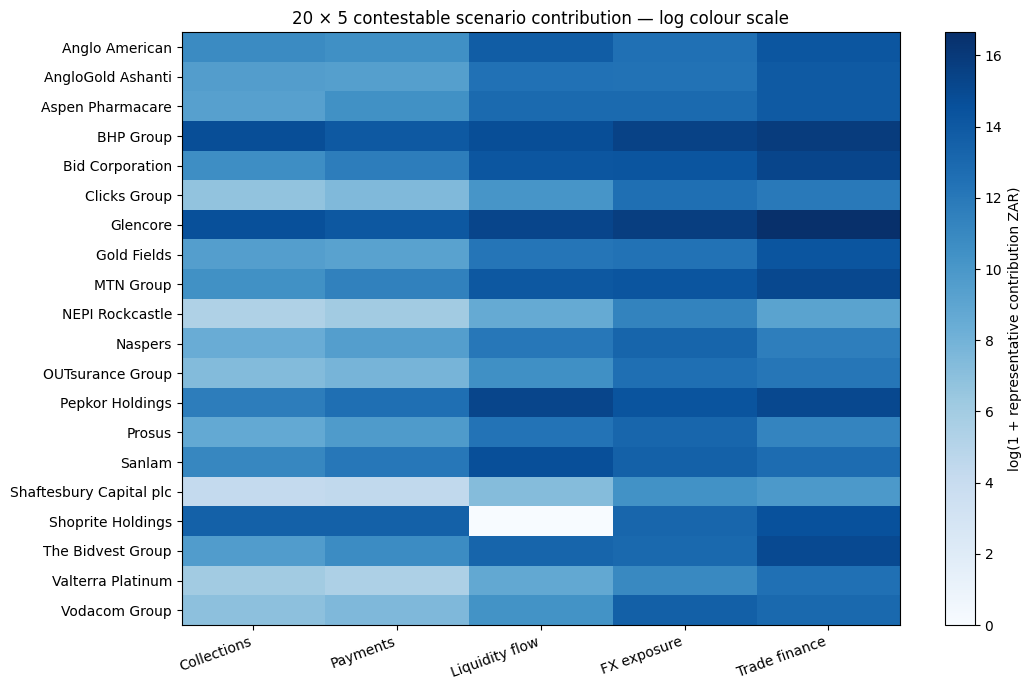

In [6]:
heat = equations.pivot(index='client', columns='product', values='scenario_contribution')
heat = heat[['Collections','Payments','Liquidity','Cross-border FX','Trade finance']]
fig, ax = plt.subplots(figsize=(11,7))
image = ax.imshow(np.log1p(heat.values), cmap='Blues', aspect='auto')
ax.set_xticks(range(5), ['Collections','Payments','Liquidity flow','FX exposure','Trade finance'], rotation=20, ha='right')
ax.set_yticks(range(20), heat.index)
ax.set_title('20 × 5 contestable scenario contribution — log colour scale')
fig.colorbar(image, ax=ax, label='log(1 + representative contribution ZAR)')
plt.tight_layout(); plt.show()
assert heat.shape == (20,5) and heat.notna().all().all()

## 6. BHP forensic drill-down: A, T, q, q*, G and cited evidence

In [7]:
bhp_cells = [cell for cell in wallet.cells if cell.entity_id == 'E01']
bhp = max(bhp_cells, key=lambda cell: cell.scenario_contribution.median if cell.scenario_contribution else 0)
detail = v31.wallet_opportunity(bhp.opportunity_id, v31.as_of)
display(pd.DataFrame([
    ['A — observed', detail.explanation['A']['value'], 'OBSERVED'],
    ['T — P10', detail.explanation['T']['p10'], 'POSTERIOR'],
    ['T — P50', detail.explanation['T']['p50'], 'POSTERIOR'],
    ['T — P90', detail.explanation['T']['p90'], 'POSTERIOR'],
    ['q — P50', detail.explanation['q']['p50'], 'POSTERIOR'],
    ['q*', detail.explanation['q_star']['value'], 'SCENARIO'],
    ['G — P50', detail.explanation['G']['p50'], 'SCENARIO'],
], columns=['quantity','value','claim_class']))
facts = pd.DataFrame(detail.supporting_facts)
display(facts[['fact_id','concept','value','currency','unit','source_title','page','source_url','qa_and_approval_state']])
assert all(facts.qa_and_approval_state == 'APPROVED_ACTIVE')

,quantity,value,claim_class
0,A — observed,1.444550e+09,OBSERVED
1,T — P10,5.152199e+09,POSTERIOR
2,T — P50,8.926977e+09,POSTERIOR
3,T — P90,2.208283e+10,POSTERIOR
4,q — P50,1.618185e-01,POSTERIOR
5,q*,4.000000e-01,SCENARIO
6,G — P50,2.126241e+09,SCENARIO


,fact_id,concept,value,currency,unit,source_title,page,source_url,qa_and_approval_state
0,BHP-2025-COST,operating_cost_base,32319.0,USD,million,BHP Annual Report 2025,118,https://www.bhp.com/-/media/documents/investor...,APPROVED_ACTIVE
1,BHP-2025-INV-OPEN,inventories_open,7039.0,USD,million,BHP Annual Report 2025,139,https://www.bhp.com/-/media/documents/investor...,APPROVED_ACTIVE
2,BHP-2025-INV-CLOSE,inventories_close,6978.0,USD,million,BHP Annual Report 2025,139,https://www.bhp.com/-/media/documents/investor...,APPROVED_ACTIVE
3,BHP-2025-AP-OPEN,trade_payables_open,5338.0,USD,million,BHP Annual Report 2025,139,https://www.bhp.com/-/media/documents/investor...,APPROVED_ACTIVE
4,BHP-2025-AP-CLOSE,trade_payables_close,5082.0,USD,million,BHP Annual Report 2025,139,https://www.bhp.com/-/media/documents/investor...,APPROVED_ACTIVE


## 7. E1 pooling sensitivity and Trade Finance dominance

In [8]:
sensitivity = json.loads((ROOT / 'outputs/v2_validation/measurement_policy_sensitivity.json').read_text())
arms = pd.DataFrame([
    {
        'e1_weight': float(weight),
        'policy_version': arm['policy_version'],
        'top_opportunity': arm['ranking'][0],
        'activated_cells': arm['activated_cells'],
        'mean_activated_interval_width': np.mean([cell['posterior_wallet_interval_width'] for cell in arm['cells'] if cell['activated']]),
    }
    for weight, arm in sensitivity['arms'].items()
])
display(arms)
trade = json.loads((ROOT / 'dashboard/app/data/shadow-fixture.json').read_text())['sensitivity']['product_summary']['Trade finance']
display(pd.Series(trade, name='Trade finance sensitivity').to_frame())
print('Conclusion:', sensitivity['headline'])
assert set(arms.e1_weight) == {0.2,0.35,0.5}

,e1_weight,policy_version,top_opportunity,activated_cells,mean_activated_interval_width
0,0.20,v2-wallet-measurement-policy-1.1.0+e1w0.20,E02-trade-finance,15,3.421047e+10
1,0.35,v2-wallet-measurement-policy-1.1.0+e1w0.35,E02-trade-finance,15,4.170769e+10
2,0.50,v2-wallet-measurement-policy-1.1.0+e1w0.50,E02-trade-finance,15,5.402858e+10


,Trade finance sensitivity
absolute_economics,"{'p05': 23194707.06, 'p50': 55277502.05, 'p95'..."
first_rank_frequency,1.0
majority_dominance_frequency,0.8775
mean_top10_share,0.55717


Conclusion: The top-8 selection is NOT invariant across 0.20-0.50; see comparisons.


## 8. Wallet gap → stakeholder, problem, solution and timing

In [9]:
action = detail.decision_twin_action
display(pd.Series(action, name='BHP action layer').to_frame())
conversation = v31.conversation(action['conversation_id'], v31.as_of)
print('30/60/90-day:', conversation.engagement_window.probability_30d, conversation.engagement_window.probability_60d, conversation.engagement_window.probability_90d)
print('Permitted action:', conversation.action.value)
assert conversation.action.value == 'DISCOVERY'

,BHP action layer
conversation_id,conv:7afe2720dd7f1a37381e2573
stakeholder_role,COO
problem,Supply-chain risk
solution_bundle,"[TRADE_FINANCE, CROSS_BORDER_FX, GUARANTEES_AN..."
why_now,106 bank-observed trade events are dated insid...
permitted_action,DISCOVERY
conditional_action,If the client confirms external wallet and req...


30/60/90-day: 0.19778325391814938 0.29667488087722405 0.38035241138105647
Permitted action: DISCOVERY


## 9. Eight-conversation plan and active-learning loop

In [10]:
plan = pd.DataFrame([entry.model_dump(mode='json') for entry in v31.plan.entries])
display(plan[['rank','entity_name','stakeholder_role','problem_label','solution_label','client_value_median','bank_value_median','selection_stability','action']])
question = conversation.next_best_question
print('Highest positive-net-VOI question:', question.question_text)
print('Net VOI:', question.net_voi_zar, '| common draws:', question.scenario_draws)
from wallet_twin_v31.questions import ClientAnswerWorkflow
workflow = ClientAnswerWorkflow(v31.as_of)
answer = workflow.submit(answer_id='notebook-answer', question=question, answer_state_id=question.answer_states[0].state_id, respondent_role=conversation.stakeholder.primary_role, respondent_type='CLIENT', consent_reference='demo-consent', scope='relationship discovery', source='demo meeting note')
print('Answer state:', answer.approval_status, '| changes approved snapshot:', answer.resulting_claim_id is not None)
assert len(plan) == 8 and answer.approval_status.value == 'PENDING_REVIEW'

,rank,entity_name,stakeholder_role,problem_label,solution_label,client_value_median,bank_value_median,selection_stability,action
0,1,Pepkor Holdings,FINANCE_OPERATIONS,Payments inefficiency,Payments,2.589160e+07,3.906298e+06,0.9583,DISCOVERY
1,2,Sanlam,FINANCE_OPERATIONS,Payments inefficiency,Payments,1.361474e+07,1.976327e+06,0.4167,DISCOVERY
2,3,Sanlam,TREASURER,Liquidity fragmentation,Liquidity and cash management,1.361474e+07,1.976327e+06,0.0000,DISCOVERY
3,4,BHP Group,TREASURER,FX exposure,Cross-border FX,1.464448e+07,8.059727e+06,0.1667,DISCOVERY
4,5,Shoprite Holdings,TREASURER,FX exposure,Cross-border FX,5.864010e+06,4.161504e+05,1.0000,DISCOVERY
5,6,MTN Group,TREASURER,FX exposure,Cross-border FX,7.055798e+06,2.146740e+06,0.6667,DISCOVERY
6,7,BHP Group,COO,Supply-chain risk,Trade finance,7.907087e+09,1.145482e+07,1.0000,DISCOVERY
7,8,Shoprite Holdings,COO,Supply-chain risk,Trade finance,2.619986e+09,1.539017e+06,0.0417,DISCOVERY


Highest positive-net-VOI question: Are any projects or SPVs currently being structured, and at what stage are they?
Net VOI: 26598.102247312083 | common draws: 512
Answer state: ApprovalStatus.PENDING_REVIEW | changes approved snapshot: False


## 10. Grounded deterministic briefs and comparative provider evaluation

In [11]:
brief = v31.brief(conversation.conversation_id, v31.as_of)
brief_markdown = '### {}\n\n**WHY** {}\n\n**HOW** {}\n\n**WHAT** {}'.format(brief.headline, brief.why, brief.how, brief.what)
display(Markdown(brief_markdown))
comparison = json.loads((ROOT / 'outputs/v2_validation/live_provider_comparison.json').read_text())
provider_rows = pd.DataFrame(comparison['evaluations'])[['entity_name','provider','canonical_model_id','execution_status','acceptance_status','latency_ms']]
display(provider_rows)
print('Accepted live runs:', comparison['accepted_runs'], '| gate:', comparison['submission_gate_passed'])
print('Fresh credentials are required; provider failures are not presented as success.')

### BHP Group Â· Coo Â· Supply-chain risk

**WHY** 106 bank-observed trade events are dated inside the next 90 days. The event is dated 2026-08-14 (45 days away) and preparation takes about 45 days, so the conversation window opens 2026-06-30. On the evidence we hold, this points to supply-chain risk. Against it: Supplier concentration and contractual terms are not disclosed.

**HOW** Trade finance, Cross-border FX, Guarantees and letters of credit. Modelled client benefit is ZAR 3,162,834,740 to ZAR 14,232,756,329 on the governed assumption set.

**WHAT** Open a discovery conversation with the Coo. This is not a product proposal: PRODUCT_CAPABILITY, CREDIT_AND_RISK, COMPLIANCE_AND_CONDUCT, OPERATIONS_AND_ONBOARDING remain unconfirmed, so the purpose is to establish the facts we are missing. The window runs 2026-06-30 to 2026-08-14. Ask first: "Are any projects or SPVs currently being structured, and at what stage are they?"

,entity_name,provider,canonical_model_id,execution_status,acceptance_status,latency_ms
0,BHP Group,openai,gpt-5.6-sol,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
1,Glencore,openai,gpt-5.6-sol,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
2,Shoprite Holdings,openai,gpt-5.6-sol,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
3,BHP Group,anthropic,claude-sonnet-5,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
4,Glencore,anthropic,claude-sonnet-5,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
5,Shoprite Holdings,anthropic,claude-sonnet-5,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
6,BHP Group,google,gemini-3.6-flash,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
7,Glencore,google,gemini-3.6-flash,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None
8,Shoprite Holdings,google,gemini-3.6-flash,FRESH_CREDENTIAL_AND_EXPLICIT_APPROVAL_REQUIRED,NOT_EXECUTED,None


Accepted live runs: 0 | gate: False
Fresh credentials are required; provider failures are not presented as success.


## 11. Validation hierarchy and release conclusion

In [12]:
hierarchy = pd.DataFrame([
    ['Mechanical', 'contracts, equations, point-in-time, authorization, reproducibility', 'PASSED'],
    ['Known truth', 'synthetic calibration and deterministic golden set', 'PASSED FOR MECHANICS'],
    ['Predictive', 'E3 wallet/share panel and qualified RM outcomes', 'OPEN'],
    ['External', 'approved economics, live providers, bank controls and pilot', 'OPEN'],
], columns=['level','evidence','status'])
display(hierarchy)
print('Hackathon software state: HACKATHON_SUBMISSION_READY after final artifact/CI gates')
print('Bank production state:', v31.release['bank_production_status'])
assert v31.validation['measured_competitor_share_claims'] == 0
assert v31.validation['causal_value_claims'] == 0
assert v31.release['bank_production_status'] == 'NOT_PROMOTABLE'

,level,evidence,status
0,Mechanical,"contracts, equations, point-in-time, authoriza...",PASSED
1,Known truth,synthetic calibration and deterministic golden...,PASSED FOR MECHANICS
2,Predictive,E3 wallet/share panel and qualified RM outcomes,OPEN
3,External,"approved economics, live providers, bank contr...",OPEN


Hackathon software state: HACKATHON_SUBMISSION_READY after final artifact/CI gates
Bank production state: NOT_PROMOTABLE


## Limitations

- 85 of 100 wallet cells are prior-led because pending public facts cannot activate anchors.
- E1 accounting proxies do not measure competitor transactions; E3 is required for a measured-share label.
- Pricing, FTP, capital, risk, cost-to-win and hurdle rates are representative, not bank-approved.
- Timing is a transparent baseline, not a qualified-RM-outcome calibrated hazard model.
- Live provider evaluation remains incomplete until fresh rotated credentials and explicit acknowledgement are supplied.
- No RM pilot or randomized trial has established causal impact.

These limitations block bank promotion but do not invalidate the reproducible hackathon demonstration.